### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,classification_report,multilabel_confusion_matrix
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.ensemble import GradientBoostingRegressor

### Create Data

In [2]:
# create some data.
nrows = 1000
df = pd.DataFrame()
df['OriginalPrice'] = np.random.random(nrows)*10000+40000
df['Age'] = np.random.random(nrows)*10
df['KM'] = df['Age']*10000 + np.random.randn(nrows)*500
df['Condition'] = np.random.choice(['Fair','Good','Excellent'],size=nrows)
df['Seller'] = np.random.choice(['Dealer','Private'],size=nrows)
df['Price'] = df['OriginalPrice']*(2**(-df['Age']/3)) - df['KM']*0.01 + 2000*(df['Condition']=='Excellent') - 2000*(df['Condition']=='Fair') + 2000*(df['Seller']=='Dealer') + np.random.randn(nrows)*1000

df

,OriginalPrice,Age,KM,Condition,Seller,Price
0,46306.187525,9.792905,97610.629541,Good,Dealer,5350.376486
1,42837.836048,2.638301,25748.870623,Fair,Private,20237.819326
2,43618.245348,4.217752,41950.528647,Good,Private,16472.904602
3,44678.877475,2.028735,21060.347008,Excellent,Dealer,30692.147292
4,43380.513928,2.766892,27194.672483,Fair,Dealer,23328.224962
...,...,...,...,...,...,...
995,40871.955326,3.303400,33376.259568,Good,Dealer,19810.311047
996,49629.298866,7.127951,71597.360510,Fair,Private,7717.460587
997,44440.725315,7.563417,75155.623506,Fair,Dealer,7190.836831
998,48374.650460,6.517189,64667.743099,Good,Private,10415.240496


### Visualization

In [3]:
# Check for nans
df.isna().sum()

OriginalPrice    0
Age              0
KM               0
Condition        0
Seller           0
Price            0
dtype: int64

In [4]:
# Summarize distribution
df.describe()

,OriginalPrice,Age,KM,Price
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,45123.827366,5.082335,50807.438386,17592.473789
std,2927.992051,2.840857,28421.524983,11350.806760
min,40018.532249,0.016953,-61.465637,-140.909841
25%,42491.449180,2.615108,25859.889997,8426.123498
50%,45111.758702,5.028970,50497.820664,14836.606393
75%,47674.209875,7.536169,75556.165073,25050.082596
max,49997.782002,9.999867,100499.996244,52020.505454


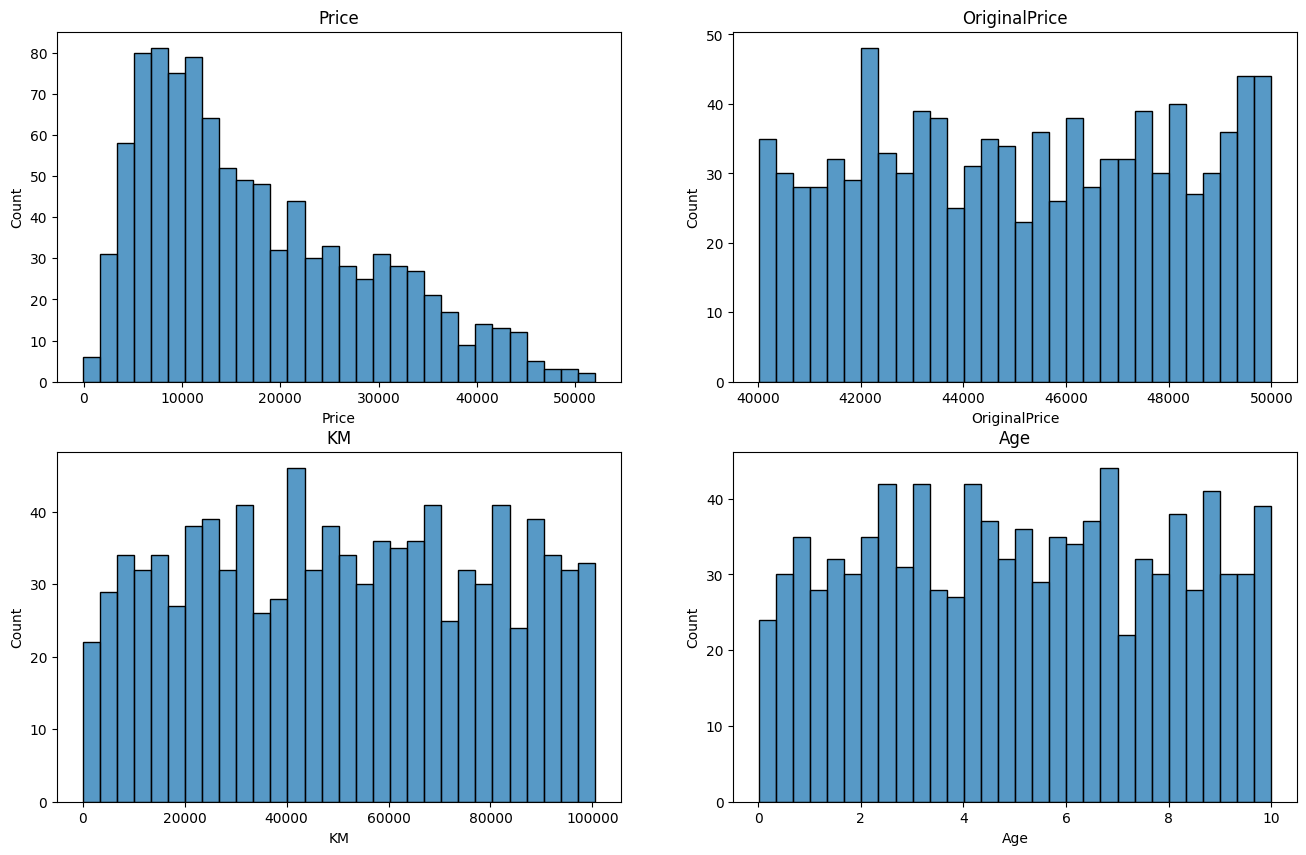

In [5]:
# Histograms of numerical data.
columns = ['Price','OriginalPrice','KM','Age']
n_display_cols = 2
n_display_rows = int(np.ceil(len(columns)/n_display_cols))
fig,axes = plt.subplots(n_display_rows,n_display_cols,figsize=(16,10))

for i,v in enumerate(columns):
    row = i//n_display_rows
    col = i-row*n_display_cols
    if n_display_rows>1:
        sns.histplot(df[v],ax=axes[row,col],bins=30)
        axes[row,col].set_title(v)    
    else:
        sns.histplot(df[v],ax=axes[col],bins=30)
        axes[col].set_title(v)

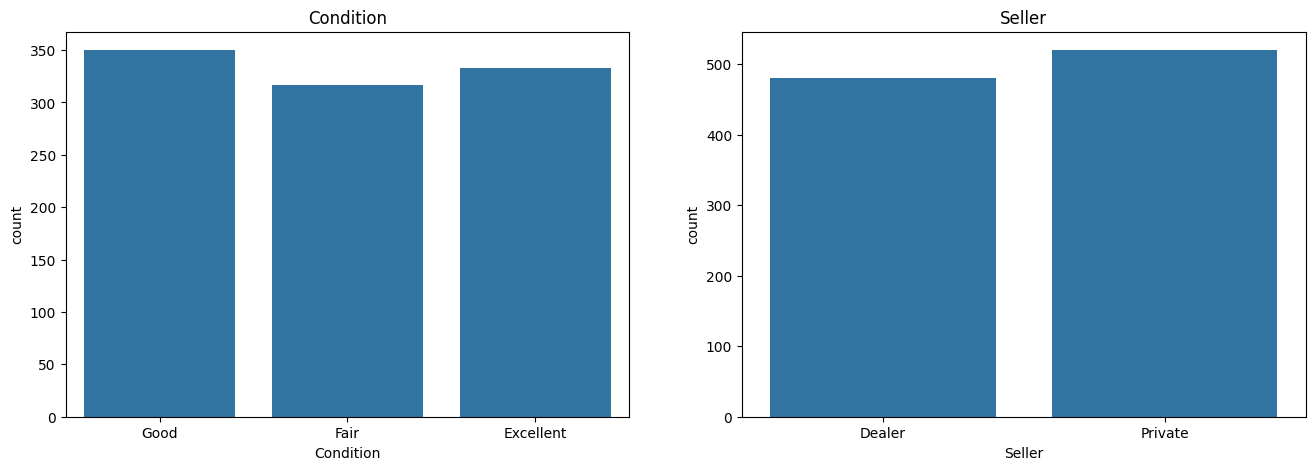

In [6]:
# Counts of levels in categorical data
columns = ['Condition','Seller']
n_display_cols = 2
n_display_rows = int(np.ceil(len(columns)/n_display_cols))
fig,axes = plt.subplots(n_display_rows,n_display_cols,figsize=(16,5))

for i,v in enumerate(columns):
    row = i//n_display_rows
    col = i-row*n_display_cols
    if n_display_rows>1:
        sns.countplot(data=df,x=v,ax=axes[row,col])
        axes[row,col].set_title(v)    
    else:
        sns.countplot(data=df,x=v,ax=axes[col])
        axes[col].set_title(v)

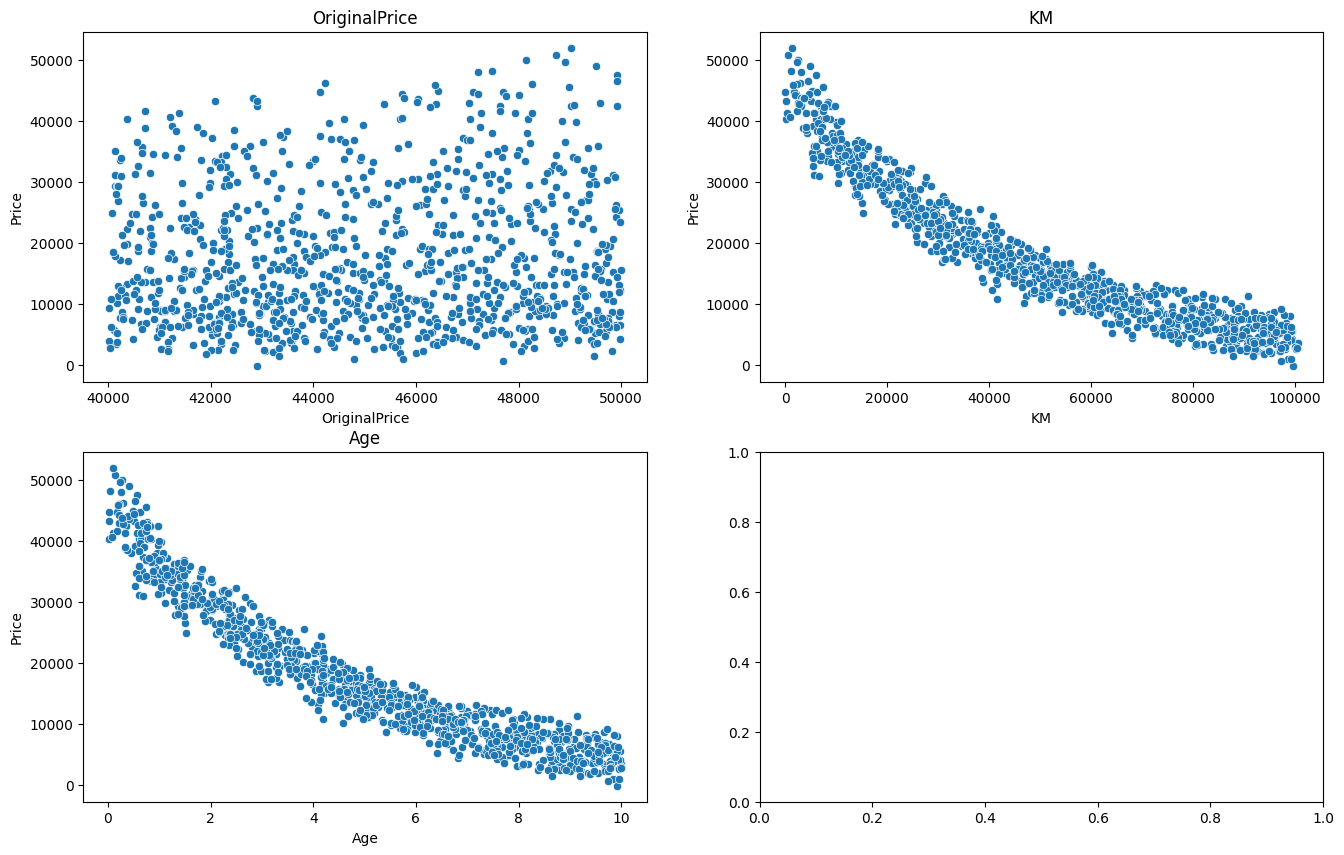

In [7]:
# Scatter of numerical data.
columns = ['OriginalPrice','KM','Age']
n_display_cols = 2
n_display_rows = int(np.ceil(len(columns)/n_display_cols))
fig,axes = plt.subplots(n_display_rows,n_display_cols,figsize=(16,10))

for i,v in enumerate(columns):
    row = i//n_display_rows
    col = i-row*n_display_cols
    if n_display_rows>1:
        sns.scatterplot(data=df,x=v,y='Price',ax=axes[row,col])
        axes[row,col].set_title(v)
    else:
        sns.scatterplot(data=df,x=v,y='Price',ax=axes[col])
        axes[col].set_title(v)

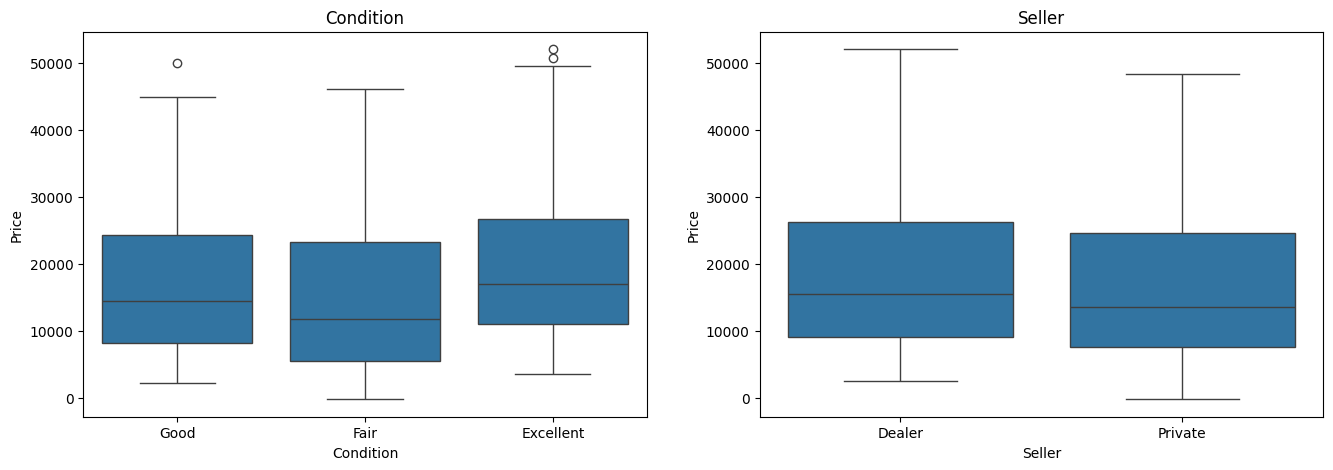

In [8]:
# Boxplot of categorical data.
columns = ['Condition','Seller']
n_display_cols = 2
n_display_rows = int(np.ceil(len(columns)/n_display_cols))
fig,axes = plt.subplots(n_display_rows,n_display_cols,figsize=(16,5))

for i,v in enumerate(columns):
    row = i//n_display_rows
    col = i-row*n_display_cols
    if n_display_rows>1:
        sns.boxplot(data=df,x=v,y='Price',ax=axes[row,col])
        axes[row,col].set_title(v)
    else:
        sns.boxplot(data=df,x=v,y='Price',ax=axes[col])
        axes[col].set_title(v)

### Transformations

In [9]:
# Dummy transformation
df_transformed = df.copy(deep=True)
cat_variables = ['Condition','Seller']
for c in cat_variables:
    df_transformed = pd.get_dummies(df_transformed,prefix=c,columns=[c],drop_first=True)
df_transformed

,OriginalPrice,Age,KM,Price,Condition_Fair,Condition_Good,Seller_Private
0,46306.187525,9.792905,97610.629541,5350.376486,False,True,False
1,42837.836048,2.638301,25748.870623,20237.819326,True,False,True
2,43618.245348,4.217752,41950.528647,16472.904602,False,True,True
3,44678.877475,2.028735,21060.347008,30692.147292,False,False,False
4,43380.513928,2.766892,27194.672483,23328.224962,True,False,False
...,...,...,...,...,...,...,...
995,40871.955326,3.303400,33376.259568,19810.311047,False,True,False
996,49629.298866,7.127951,71597.360510,7717.460587,True,False,True
997,44440.725315,7.563417,75155.623506,7190.836831,True,False,False
998,48374.650460,6.517189,64667.743099,10415.240496,False,True,True


In [10]:
# Scaling
numerical_variables = ['OriginalPrice','Age','KM']
scaler = StandardScaler()
df_transformed[numerical_variables] = scaler.fit_transform(df_transformed[numerical_variables])
df_transformed

,OriginalPrice,Age,KM,Price,Condition_Fair,Condition_Good,Seller_Private
0,0.404015,1.658981,1.647576,5350.376486,False,True,False
1,-0.781128,-0.860746,-0.882117,20237.819326,True,False,True
2,-0.514460,-0.304491,-0.311783,16472.904602,False,True,True
3,-0.152040,-1.075425,-1.047163,30692.147292,False,False,False
4,-0.595693,-0.815459,-0.831221,23328.224962,True,False,False
...,...,...,...,...,...,...,...
995,-1.452873,-0.626510,-0.613616,19810.311047,False,True,False
996,1.539528,0.720430,0.731851,7717.460587,True,False,True
997,-0.233417,0.873794,0.857110,7190.836831,True,False,False
998,1.110812,0.505331,0.487913,10415.240496,False,True,True


### Modeling

In [11]:
# train-test split
X,y = df_transformed.loc[:,~df_transformed.columns.isin(['Price'])],df_transformed['Price']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
lasso_regressor = Lasso().fit(X_train,y_train)
lasso_regressor_predictions = lasso_regressor.predict(X_test)
mse_lasso = mean_squared_error(y_test,lasso_regressor_predictions)
mse_lasso

11116127.927850824

In [13]:
gbm = GradientBoostingRegressor().fit(X_train,y_train)
gbm_predictions = gbm.predict(X_test)
mse_gbm = mean_squared_error(y_test,gbm_predictions)
mse_gbm

1263465.3081079752

In [14]:
chosen_predictions = pd.DataFrame(index=y_test.index)
chosen_predictions['PricePredicted'] = lasso_regressor_predictions if mse_lasso < mse_gbm else gbm_predictions
chosen_predictions

,PricePredicted
521,12435.851028
737,9113.561022
740,3981.627538
660,36931.083157
411,33729.341766
...,...
408,23958.254880
332,11844.067866
208,4809.213647
613,39281.989778


### Assessment 

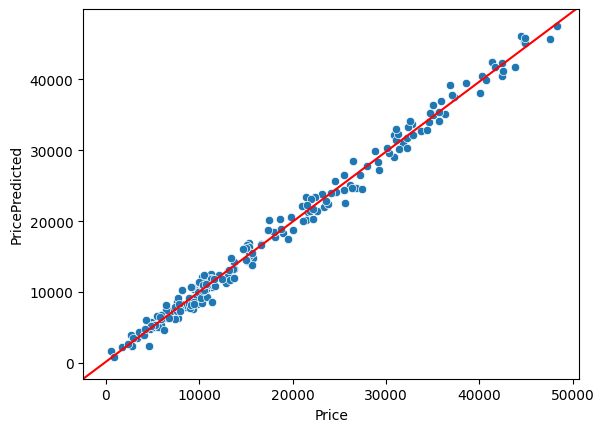

In [15]:
combined = pd.concat([chosen_predictions,y_test],axis=1)
sns.scatterplot(x=combined['Price'],y=combined['PricePredicted'])
ols = LinearRegression().fit(X=combined[['Price']],y=combined[['PricePredicted']])
intercept,slope = ols.intercept_[0],ols.coef_[0][0]
plt.axline((0,intercept),slope=slope,color='red')

<Axes: >

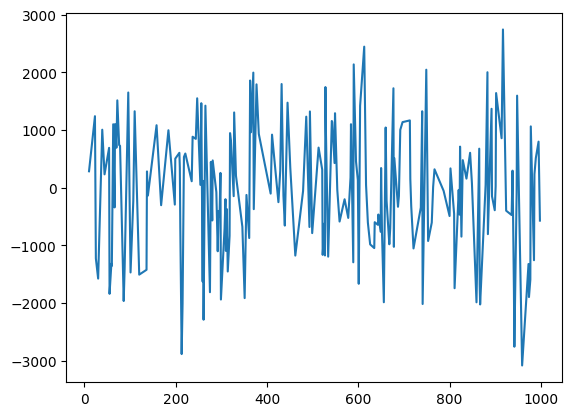

In [16]:
residuals = combined['PricePredicted']-combined['Price']
sns.lineplot(residuals)